In [102]:
import pandas as pd
import folium
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [22]:
!pip install folium

In [10]:
df = pd.read_csv("C:/Users/hp/Downloads/delhi-metro-network-1/Delhi-Metro-Network.csv")

In [13]:
df.head()

,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
0,1,Jhil Mil,10.3,Red line,2008-04-06,Elevated,28.675790,77.312390
1,2,Welcome [Conn: Red],46.8,Pink line,2018-10-31,Elevated,28.671800,77.277560
2,3,DLF Phase 3,10.0,Rapid Metro,2013-11-14,Elevated,28.493600,77.093500
3,4,Okhla NSIC,23.8,Magenta line,2017-12-25,Elevated,28.554483,77.264849
4,5,Dwarka Mor,10.2,Blue line,2005-12-30,Elevated,28.619320,77.033260


In [12]:
df.isnull().sum()

Station ID                  0
Station Name                0
Distance from Start (km)    0
Line                        0
Opening Date                0
Station Layout              0
Latitude                    0
Longitude                   0
dtype: int64

In [15]:
df.dtypes

Station ID                    int64
Station Name                 object
Distance from Start (km)    float64
Line                         object
Opening Date                 object
Station Layout               object
Latitude                    float64
Longitude                   float64
dtype: object

In [16]:
df["Opening Date"] = pd.to_datetime(df["Opening Date"])

In [17]:
df.head()

,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
0,1,Jhil Mil,10.3,Red line,2008-04-06,Elevated,28.675790,77.312390
1,2,Welcome [Conn: Red],46.8,Pink line,2018-10-31,Elevated,28.671800,77.277560
2,3,DLF Phase 3,10.0,Rapid Metro,2013-11-14,Elevated,28.493600,77.093500
3,4,Okhla NSIC,23.8,Magenta line,2017-12-25,Elevated,28.554483,77.264849
4,5,Dwarka Mor,10.2,Blue line,2005-12-30,Elevated,28.619320,77.033260


In [18]:
df.dtypes

Station ID                           int64
Station Name                        object
Distance from Start (km)           float64
Line                                object
Opening Date                datetime64[ns]
Station Layout                      object
Latitude                           float64
Longitude                          float64
dtype: object

In [33]:
line_colors = {
    'Red line': 'red',
    'Blue line': 'blue',
    'Yellow line': 'beige',
    'Green line': 'green',
    'Voilet line': 'purple',
    'Pink line': 'pink',
    'Magenta line': 'darkred',
    'Orange line': 'orange',
    'Rapid Metro': 'cadetblue',
    'Aqua line': 'black',
    'Green line branch': 'lightgreen',
    'Blue line branch': 'lightblue',
    'Gray line': 'lightgray'
}

In [34]:
delhi_map_with_line_tooltip = folium.Map(location=[28.7041, 77.1025], zoom_start=11)


In [35]:
for index, row in df.iterrows():
    line = row['Line']
    color = line_colors.get(line, 'black')  # Default color is black if line not found in the dictionary
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"{row['Station Name']}",
        tooltip=f"{row['Station Name']}, {line}",
        icon=folium.Icon(color=color)
    ).add_to(delhi_map_with_line_tooltip)


In [36]:
delhi_map_with_line_tooltip

In [53]:
df['Opening Year'] = df['Opening Date'].dt.year

In [54]:
stations_per_year = df['Opening Year'].value_counts().sort_index()

In [55]:
stations_per_year_dfa = stations_per_year.reset_index()

In [56]:
stations_per_year_dfa.columns = ['Year', 'Number of Stations']

In [57]:
fig = px.bar(stations_per_year_dfa, x='Year', y='Number of Stations',
             title="Number of Metro Stations Opened Each Year in Delhi",
             labels={'Year': 'Year', 'Number of Stations': 'Number of Stations Opened'})


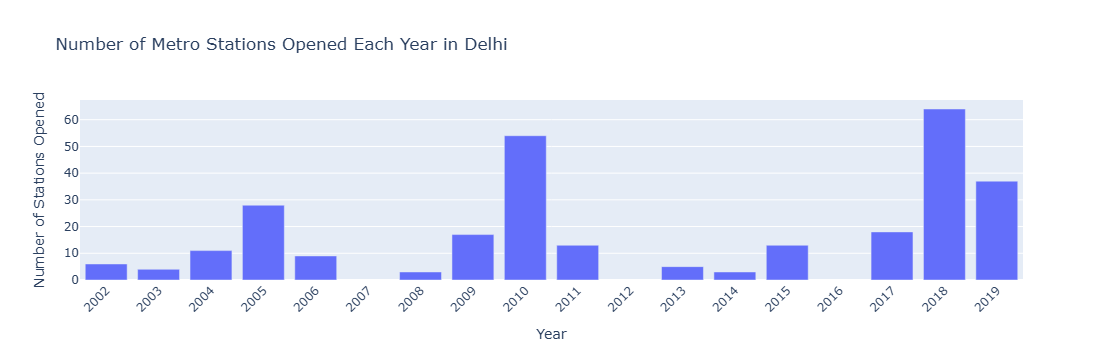

In [88]:
fig.update_layout(
    xaxis_tickangle=-45,
    xaxis=dict(tickmode='linear'),
    yaxis=dict(
        title='Number of Stations Opened',
        # tickmode='linear', for equal spacing bars 
        tick0=0,     # starting tick
        dtick=10     # interval of 10
    ),
    xaxis_title="Year"
)
fig.show()

In [90]:
stations_per_line = df['Line'].value_counts()

In [92]:
total_distance_per_line = df.groupby('Line')['Distance from Start (km)'].max()


In [93]:
avg_distance_per_line = total_distance_per_line / (stations_per_line - 1)


In [94]:
line_analysis = pd.DataFrame({
    'Line': stations_per_line.index,
    'Number of Stations': stations_per_line.values,
    'Average Distance Between Stations (km)': avg_distance_per_line
})

In [95]:
line_analysis = line_analysis.sort_values(by='Number of Stations', ascending=False)

line_analysis.reset_index(drop=True, inplace=True)
print(line_analysis)

                 Line  Number of Stations  \
0           Blue line                  49   
1           Pink line                  38   
2         Yellow line                  37   
3         Voilet line                  34   
4            Red line                  29   
5        Magenta line                  25   
6           Aqua line                  21   
7          Green line                  21   
8         Rapid Metro                  11   
9    Blue line branch                   8   
10        Orange line                   6   
11          Gray line                   3   
12  Green line branch                   3   

    Average Distance Between Stations (km)  
0                                 1.355000  
1                                 1.097917  
2                                 1.157143  
3                                 1.950000  
4                                 1.240000  
5                                 1.050000  
6                                 1.379167  
7        

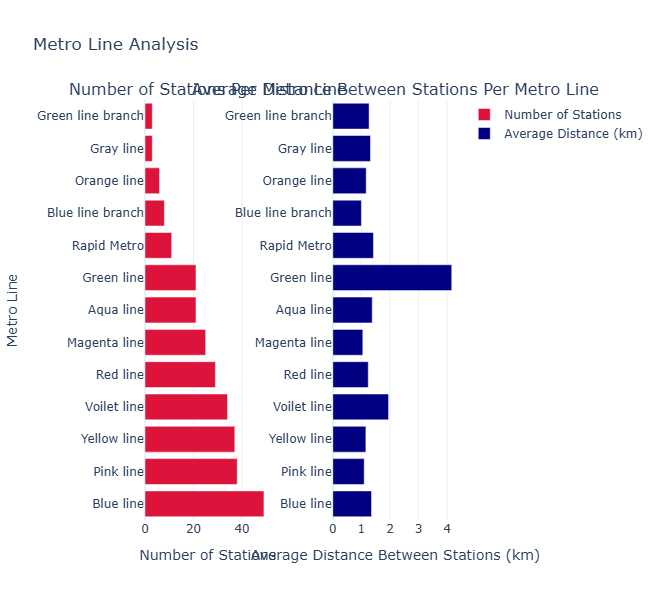

In [119]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Number of Stations Per Metro Line',
                                                    'Average Distance Between Stations Per Metro Line'),
                    horizontal_spacing=0.2)

fig.add_trace(
    go.Bar(y=line_analysis['Line'], x=line_analysis['Number of Stations'],
           orientation='h', name='Number of Stations', marker_color='crimson'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(y=line_analysis['Line'], x=line_analysis['Average Distance Between Stations (km)'],
           orientation='h', name='Average Distance (km)', marker_color='navy'),
    row=1, col=2
)

fig.update_xaxes(title_text="Number of Stations", row=1, col=1)
fig.update_xaxes(title_text="Average Distance Between Stations (km)", row=1, col=2)

fig.update_yaxes(title_text="Metro Line", row=1, col=1)
fig.update_yaxes(title_text="", row=1, col=2)

fig.update_layout(height=600, width=1200, title_text="Metro Line Analysis", template="plotly_white")

fig.show()

In [109]:
layout_counts = df['Station Layout'].value_counts()

In [110]:
fig = px.bar(x=layout_counts.index, y=layout_counts.values,
             labels={'x': 'Station Layout', 'y': 'Number of Stations'},
             title='Distribution of Delhi Metro Station Layouts',
             color=layout_counts.index,
             color_continuous_scale='pastel')

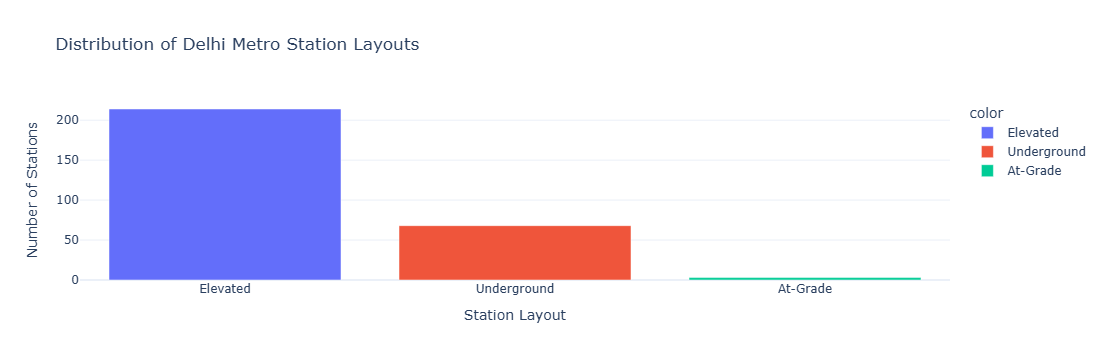

In [111]:
fig.update_layout(xaxis_title="Station Layout",
                  yaxis_title="Number of Stations",
                  coloraxis_showscale=False,
                  template="plotly_white")

fig.show()